# 04 - Treinamento e Avaliação do Modelo

Neste notebook, treinamos e comparamos diferentes modelos de regressão para estimar a pegada de carbono. Começamos com um baseline linear e progredimos para modelos de conjunto (*ensemble*) como Random Forest.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import os

# Semente aleatória para reprodutibilidade
np.random.seed(42)

## 1. Carregamento e Preparação dos Dados

Carregamos o dataset e preparamos as features temporais baseadas nos insights do EDA.

In [19]:
# Carregar o dataset
data_path = 'https://raw.githubusercontent.com/carbon-footprint-analysis/carbon-footprint-analysis/refs/heads/main/data/processed/synthetic_energy_emissions_dataset.csv'
df = pd.read_csv(data_path)

# Engenharia de features temporal
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month

def get_season(month):
    if month in [12, 1, 2]: return 'Verao'
    if month in [3, 4, 5]: return 'Outono'
    if month in [6, 7, 8]: return 'Inverno'
    return 'Primavera'

df['season'] = df['month'].apply(get_season)

# Seleção de atributos e target
target = 'co2_emission'
# Removemos o target e colunas não-preditivas (IDs e Datas brutas)
X = df.drop(columns=[target, 'company_id', 'date'])
y = df[target]

# Divisão Treino/Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Treino: {X_train.shape}, Teste: {X_test.shape}")

Treino: (80000, 9), Teste: (20000, 9)


## 2. Pipeline de Pré-processamento

Definimos o processamento comum para todos os modelos.

In [20]:
# Definição das colunas
numeric_features = ['energy_kwh', 'month']
categorical_features = ['state', 'usage_type', 'energy_source', 'season']

# Transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

## 3. Modelo Baseline: Regressão Linear

Treinamos o modelo simples para referência.

In [21]:
# Pipeline Linear
model_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)

print(f"Regressão Linear - R²: {r2_score(y_test, y_pred_lr):.4f}")

Regressão Linear - R²: 0.4438


In [23]:
import pandas as pd

# nomes das features após o preprocessamento
feature_names = model_lr.named_steps['preprocessor'].get_feature_names_out()

# coeficientes da regressão linear
coefficients = model_lr.named_steps['regressor'].coef_

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "coeficiente": coefficients
}).sort_values("coeficiente", key=abs, ascending=False)

print(feat_imp)

                        feature  coeficiente
37   cat__energy_source_thermal  8421.316508
0               num__energy_kwh  4272.702439
38      cat__energy_source_wind -2247.788085
35   cat__energy_source_nuclear -2134.662294
34     cat__energy_source_hydro -2045.194575
36     cat__energy_source_solar -1993.671553
28                cat__state_TO   537.004613
2                 cat__state_AC   373.668632
7                 cat__state_CE  -308.131188
16                cat__state_PB   262.157077
9                 cat__state_ES  -216.665622
19                cat__state_PR  -216.236581
13                cat__state_MS   205.056663
15                cat__state_PA  -202.654101
21                cat__state_RN  -158.539793
25                cat__state_SC  -135.533550
30   cat__usage_type_industrial  -127.177939
22                cat__state_RO  -121.439184
6                 cat__state_BA  -115.565260
3                 cat__state_AL   103.197701
14                cat__state_MT    97.522060
27        

## 4. Modelo Avançado: Random Forest

Testamos um modelo de árvore de decisão para capturar relações não-lineares.

In [24]:
# Pipeline Random Forest
model_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1))
])

model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

r2_original = r2_score(y_test, y_pred_rf)
print(f"Random Forest - R²: {r2_original:.4f}")

Random Forest - R²: 0.9948


In [25]:
import pandas as pd

feature_names = model_rf.named_steps['preprocessor'].get_feature_names_out()
importances = model_rf.named_steps['regressor'].feature_importances_

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print(feat_imp)

                        feature    importance
0               num__energy_kwh  7.652678e-01
37   cat__energy_source_thermal  2.332602e-01
1                    num__month  3.734400e-04
38      cat__energy_source_wind  1.471662e-04
6                 cat__state_BA  1.432479e-04
39          cat__season_Inverno  6.737160e-05
12                cat__state_MG  6.734287e-05
15                cat__state_PA  6.676385e-05
27                cat__state_SP  6.461150e-05
42            cat__season_Verao  5.328394e-05
11                cat__state_MA  4.264582e-05
20                cat__state_RJ  4.071216e-05
41        cat__season_Primavera  4.011259e-05
10                cat__state_GO  3.897635e-05
3                 cat__state_AL  3.658445e-05
40           cat__season_Outono  3.473710e-05
19                cat__state_PR  3.092058e-05
14                cat__state_MT  2.878176e-05
24                cat__state_RS  2.865149e-05
25                cat__state_SC  2.534271e-05
16                cat__state_PB  2

/tmp/ipykernel_41659/1106325788.py:29: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


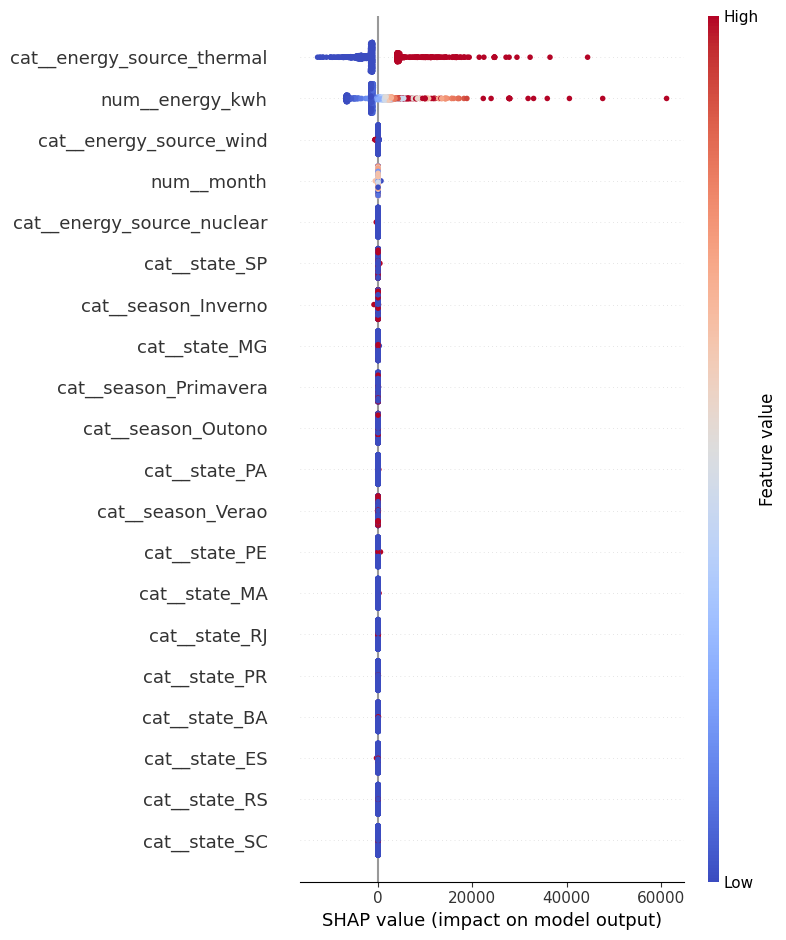

In [26]:
import shap
import matplotlib.pyplot as plt

# transformar dados
X_test_transformed = model_rf.named_steps["preprocessor"].transform(X_test)

# converter sparse -> numpy
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

X_test_transformed = X_test_transformed.astype(float)

# pegar nomes das features
feature_names = model_rf.named_steps["preprocessor"].get_feature_names_out()

# modelo RF
rf_model = model_rf.named_steps["regressor"]

# limitar amostra para não travar
X_sample = X_test_transformed[:1000]

# explainer
explainer = shap.TreeExplainer(rf_model)

# calcular shap
shap_values = explainer.shap_values(X_sample)

# gráfico
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names,
    cmap="coolwarm"
)

## 5. Comparação de Performance

Análise visual das métricas.

,Model,R2,MAE,RMSE
0,Linear Regression,0.443785,4212.130856,6821.660763
1,Random Forest,0.994805,149.205084,659.287557


/tmp/ipykernel_41659/3088894683.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results, x='Model', y='R2', palette='coolwarm')


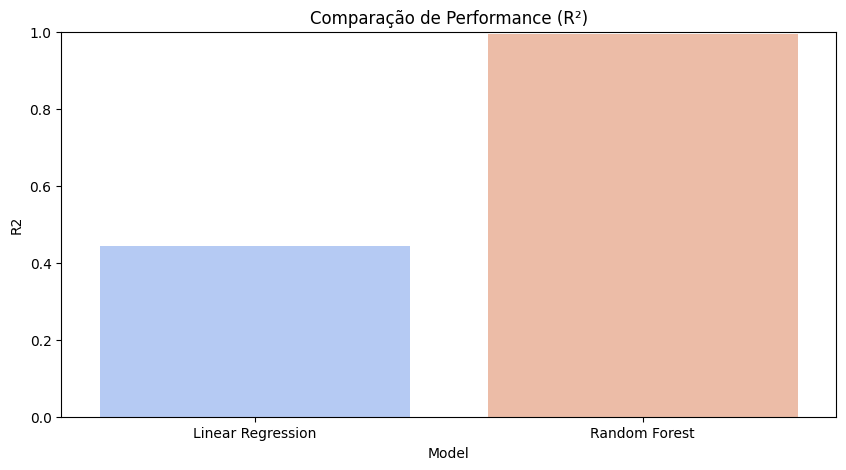

In [27]:
def get_metrics(y_true, y_pred, name):
    return {
        'Model': name,
        'R2': r2_score(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred))
    }

results = pd.DataFrame([
    get_metrics(y_test, y_pred_lr, 'Linear Regression'),
    get_metrics(y_test, y_pred_rf, 'Random Forest')
])

display(results)

# Plot comparativo
plt.figure(figsize=(10, 5))
sns.barplot(data=results, x='Model', y='R2', palette='coolwarm')
plt.title('Comparação de Performance (R²)')
plt.ylim(0, 1)
plt.show()

## 6. Importância das Features (Random Forest)

Identificamos quais variáveis mais influenciam o cálculo de CO2.

/tmp/ipykernel_41659/2367512818.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df.head(10), x='importance', y='feature', palette='magma')


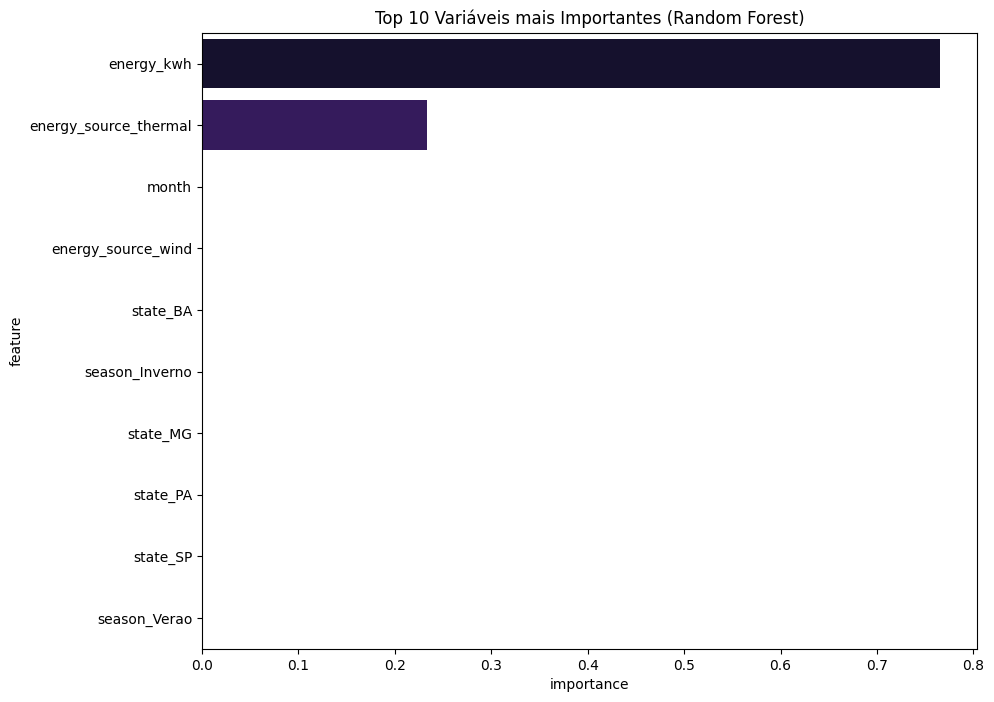

In [28]:
# Extração dos nomes das colunas após OneHotEncoding
ohe_feature_names = model_rf.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
feature_names = numeric_features + list(ohe_feature_names)

# Importâncias
importances = model_rf.named_steps['regressor'].feature_importances_
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance_df.head(10), x='importance', y='feature', palette='magma')
plt.title('Top 10 Variáveis mais Importantes (Random Forest)')
plt.show()

## 7. Teste de Robustez (Stress Test)

Simulamos imprevistos do mundo real ao adicionar ruído de 5% aos dados de consumo energético.

In [29]:
# Simulação de ruído (5% de desvio padrão do consumo)
X_test_noisy = X_test.copy()

# Calcula a escala do ruído (5% do consumo medido)
noise_scale = X_test_noisy['energy_kwh'] * 0.05
noise = np.random.normal(0, 1, size=len(X_test_noisy)) * noise_scale

X_test_noisy['energy_kwh'] += noise

# Predições no conjunto ruidoso
y_pred_noisy = model_rf.predict(X_test_noisy)

# Métricas ruidosas
r2_noisy = r2_score(y_test, y_pred_noisy)
mae_noisy = mean_absolute_error(y_test, y_pred_noisy)

print(f"--- Teste de Robustez (5% Ruído) ---")
print(f"R² Original (Sem Ruído): {r2_original:.4f}")
print(f"R² Ruidoso (Com 5% de Ruído): {r2_noisy:.4f}")
print(f"Queda Relativa no R²: {((r2_original - r2_noisy) / r2_original) * 100:.2f}%")
print(f"Novo MAE: {mae_noisy:.2f} kg CO2")

--- Teste de Robustez (5% Ruído) ---
R² Original (Sem Ruído): 0.9948
R² Ruidoso (Com 5% de Ruído): 0.9920
Queda Relativa no R²: 0.28%
Novo MAE: 187.21 kg CO2
